01 - Build a clean and reproducible market data pipeline that loads Treasury and/or SOFR market quotes, converts them into a usable term structure format, and prepares the data for yield curve bootstrapping.

What a is yield curve? 
Treasury securities as risk-free benchmarks
Difference between:
Treasury Bills
Treasury Notes
Treasury Bonds
Why yield curve construction is important

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from datetime import datetime
from pandas_datareader import data as web

In [26]:
series = {
    "3M": "DGS3MO",
    "6M": "DGS6MO",
    "1Y": "DGS1",
    "2Y": "DGS2",
    "3Y": "DGS3",
    "5Y": "DGS5",
    "7Y": "DGS7",
    "10Y": "DGS10",
    "20Y": "DGS20",
    "30Y": "DGS30"
}

end = datetime.today()
start = end - pd.DateOffset(days=30)

treasury = pd.DataFrame()

for maturity, fred_code in series.items():
    treasury[maturity] = web.DataReader(
        fred_code,
        "fred",
        start,
        end
    )[fred_code]



In [27]:
treasury

,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
DATE,,,,,,,,,,
2026-06-15,3.79,3.81,3.84,4.07,4.10,4.18,4.32,4.47,4.97,4.97
2026-06-16,3.79,3.81,3.84,4.05,4.08,4.16,4.28,4.43,4.92,4.93
2026-06-17,3.83,3.91,3.98,4.20,4.23,4.27,4.37,4.49,4.95,4.93
2026-06-18,3.83,3.92,4.00,4.19,4.19,4.23,4.34,4.46,4.91,4.90
2026-06-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22,3.85,3.98,4.04,4.24,4.25,4.29,4.39,4.51,4.97,4.95
2026-06-23,3.85,3.96,4.01,4.16,4.22,4.27,4.38,4.50,4.96,4.94
2026-06-24,3.85,3.95,3.99,4.11,4.15,4.17,4.28,4.41,4.87,4.86
2026-06-25,3.84,3.95,3.96,4.09,4.13,4.15,4.26,4.40,4.87,4.86


In [28]:
latest_curve = treasury.ffill().iloc[-1]

curve = (
    latest_curve
    .rename("Yield")
    .reset_index()
    .rename(columns={"index": "Maturity"})
)

curve

,Maturity,Yield
0,3M,3.83
1,6M,3.96
2,1Y,4.02
3,2Y,4.16
4,3Y,4.18
5,5Y,4.27
6,7Y,4.40
7,10Y,4.54
8,20Y,5.06
9,30Y,5.05


In [29]:
def maturity_to_years(maturity: str) -> float:
    if maturity.endswith("M"):
        return int(maturity[:-1]) / 12
    elif maturity.endswith("Y"):
        return int(maturity[:-1])
    else:
        raise ValueError(f"Invalid maturity format: {maturity}")

curve["Years"] = curve["Maturity"].apply(maturity_to_years)
curve

,Maturity,Yield,Years
0,3M,3.83,0.25
1,6M,3.96,0.50
2,1Y,4.02,1.00
3,2Y,4.16,2.00
4,3Y,4.18,3.00
5,5Y,4.27,5.00
6,7Y,4.40,7.00
7,10Y,4.54,10.00
8,20Y,5.06,20.00
9,30Y,5.05,30.00


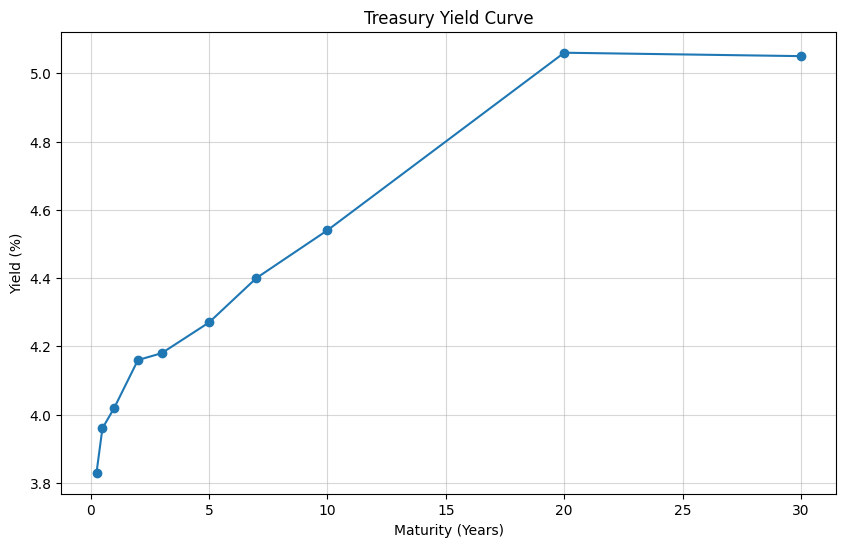

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(curve["Years"], curve["Yield"], marker='o')

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Treasury Yield Curve")
plt.grid(alpha = 0.5)


In [31]:
curve["Discount Factor"] = (1 / (1 + curve["Yield"] / 100) ** curve["Years"])
curve

,Maturity,Yield,Years,Discount Factor
0,3M,3.83,0.25,0.990648
1,6M,3.96,0.50,0.980769
2,1Y,4.02,1.00,0.961354
3,2Y,4.16,2.00,0.921718
4,3Y,4.18,3.00,0.884396
5,5Y,4.27,5.00,0.811340
6,7Y,4.40,7.00,0.739770
7,10Y,4.54,10.00,0.641468
8,20Y,5.06,20.00,0.372608
9,30Y,5.05,30.00,0.228096


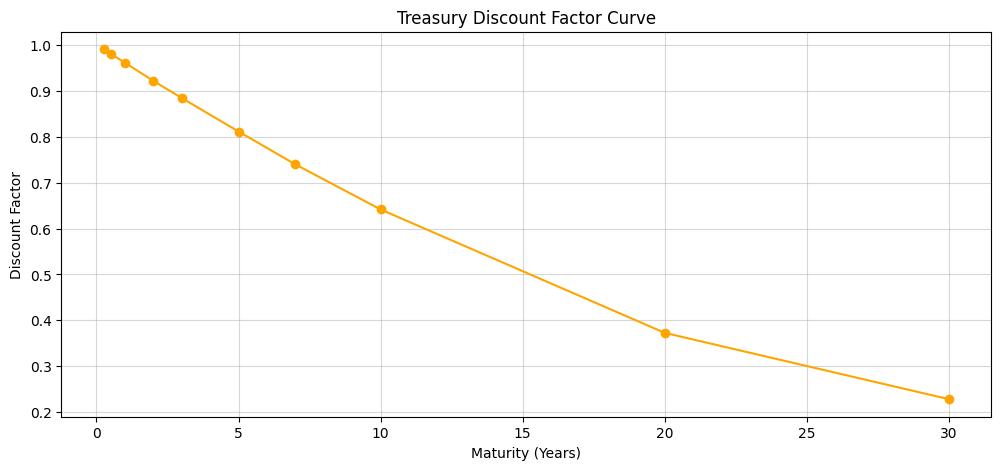

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(curve["Years"], curve["Discount Factor"], marker='o', color='orange')
plt.xlabel("Maturity (Years)")
plt.ylabel("Discount Factor")
plt.title("Treasury Discount Factor Curve")
plt.grid(alpha=0.5)

In [33]:

curve.to_csv("data/clean_treasury_curve.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'data'